In [1]:
!wget https://files.grouplens.org/datasets/movielens/ml-100k.zip

--2026-07-26 06:44:20--  https://files.grouplens.org/datasets/movielens/ml-100k.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4924029 (4.7M) [application/zip]
Saving to: ‘ml-100k.zip’

ml-100k.zip         100%[===================>]   4.70M  27.8MB/s    in 0.2s    

2026-07-26 06:44:21 (27.8 MB/s) - ‘ml-100k.zip’ saved [4924029/4924029]



In [2]:
!unzip ml-100k.zip

Archive:  ml-100k.zip
   creating: ml-100k/
  inflating: ml-100k/allbut.pl       
  inflating: ml-100k/mku.sh          
  inflating: ml-100k/README          
  inflating: ml-100k/u.data          
  inflating: ml-100k/u.genre         
  inflating: ml-100k/u.info          
  inflating: ml-100k/u.item          
  inflating: ml-100k/u.occupation    
  inflating: ml-100k/u.user          
  inflating: ml-100k/u1.base         
  inflating: ml-100k/u1.test         
  inflating: ml-100k/u2.base         
  inflating: ml-100k/u2.test         
  inflating: ml-100k/u3.base         
  inflating: ml-100k/u3.test         
  inflating: ml-100k/u4.base         
  inflating: ml-100k/u4.test         
  inflating: ml-100k/u5.base         
  inflating: ml-100k/u5.test         
  inflating: ml-100k/ua.base         
  inflating: ml-100k/ua.test         
  inflating: ml-100k/ub.base         
  inflating: ml-100k/ub.test         


In [3]:
!ls ml-100k

allbut.pl  u1.base  u2.test  u4.base  u5.test  ub.base	u.genre  u.occupation
mku.sh	   u1.test  u3.base  u4.test  ua.base  ub.test	u.info	 u.user
README	   u2.base  u3.test  u5.base  ua.test  u.data	u.item


In [5]:
import pandas as pd
ratings = pd.read_csv(
    "ml-100k/u.data",
    sep="\t",
    names=["UserID","MovieID","Rating","Timestamp"]
)

movies = pd.read_csv(
    "ml-100k/u.item",
    sep="|",
    encoding="latin-1",
    header=None,
    usecols=[0,1],
    names=["MovieID","MovieName"]
)

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
plt.style.use("ggplot")

In [9]:
ratings = pd.read_csv(

    "ml-100k/u.data",

    sep="\t",

    names=[

        "UserID",

        "MovieID",

        "Rating",

        "Timestamp"

    ]

)

ratings.head()

,UserID,MovieID,Rating,Timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [10]:
movies = pd.read_csv(

    "ml-100k/u.item",

    sep="|",                   # Pipe Separated File

    encoding="latin-1",        # Special Characters Read Karne Ke Liye

    header=None,

    usecols=[0,1],

    names=[

        "MovieID",

        "MovieName"

    ]

)

movies.head()

,MovieID,MovieName
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [11]:
ratings.head()

,UserID,MovieID,Rating,Timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [12]:
movies.head()

,MovieID,MovieName
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [13]:
print("Ratings Shape :", ratings.shape)

print("Movies Shape :", movies.shape)

Ratings Shape : (100000, 4)
Movies Shape : (1682, 2)


In [14]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   UserID     100000 non-null  int64
 1   MovieID    100000 non-null  int64
 2   Rating     100000 non-null  int64
 3   Timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [15]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1682 entries, 0 to 1681
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   MovieID    1682 non-null   int64 
 1   MovieName  1682 non-null   object
dtypes: int64(1), object(1)
memory usage: 26.4+ KB


In [16]:
ratings.isnull().sum()
movies.isnull().sum()

,0
MovieID,0
MovieName,0


In [17]:
df = pd.merge(

    ratings,

    movies,

    on="MovieID"

)

df.head()

,UserID,MovieID,Rating,Timestamp,MovieName
0,196,242,3,881250949,Kolya (1996)
1,186,302,3,891717742,L.A. Confidential (1997)
2,22,377,1,878887116,Heavyweights (1994)
3,244,51,2,880606923,Legends of the Fall (1994)
4,166,346,1,886397596,Jackie Brown (1997)


In [19]:
print(df.shape)

(100000, 5)


In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   UserID     100000 non-null  int64 
 1   MovieID    100000 non-null  int64 
 2   Rating     100000 non-null  int64 
 3   Timestamp  100000 non-null  int64 
 4   MovieName  100000 non-null  object
dtypes: int64(4), object(1)
memory usage: 3.8+ MB


In [21]:
df.describe()

,UserID,MovieID,Rating,Timestamp
count,100000.00000,100000.000000,100000.000000,1.000000e+05
mean,462.48475,425.530130,3.529860,8.835289e+08
std,266.61442,330.798356,1.125674,5.343856e+06
min,1.00000,1.000000,1.000000,8.747247e+08
25%,254.00000,175.000000,3.000000,8.794487e+08
50%,447.00000,322.000000,4.000000,8.828269e+08
75%,682.00000,631.000000,4.000000,8.882600e+08
max,943.00000,1682.000000,5.000000,8.932866e+08


In [22]:
print("Total Users :", df["UserID"].nunique())

Total Users : 943


In [23]:
print("Total Movies :", df["MovieID"].nunique())

Total Movies : 1682


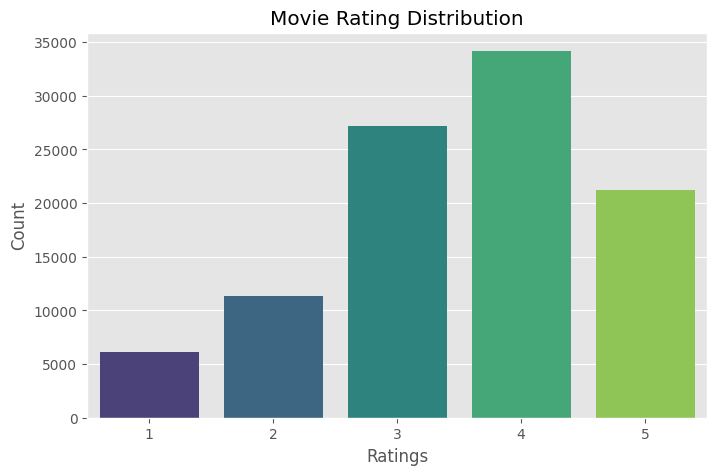

In [24]:
plt.figure(figsize=(8,5))

sns.countplot(

    x="Rating",

    data=df,

    palette="viridis"

)

plt.title("Movie Rating Distribution")

plt.xlabel("Ratings")

plt.ylabel("Count")

plt.show()

In [25]:
df["MovieName"].value_counts().head(10)

,count
MovieName,
Star Wars (1977),583
Contact (1997),509
Fargo (1996),508
Return of the Jedi (1983),507
Liar Liar (1997),485
"English Patient, The (1996)",481
Scream (1996),478
Toy Story (1995),452
Air Force One (1997),431


In [26]:
df.groupby("MovieName")["Rating"].mean().sort_values(

    ascending=False

).head(10)

,Rating
MovieName,
Aiqing wansui (1994),5.0
Entertaining Angels: The Dorothy Day Story (1996),5.0
Santa with Muscles (1996),5.0
Prefontaine (1997),5.0
They Made Me a Criminal (1939),5.0
"Saint of Fort Washington, The (1993)",5.0
"Great Day in Harlem, A (1994)",5.0
Star Kid (1997),5.0
Marlene Dietrich: Shadow and Light (1996),5.0


In [27]:
movie_matrix = df.pivot_table(

    index="UserID",          # Rows -> Users

    columns="MovieName",     # Columns -> Movies

    values="Rating"          # Values -> Ratings

)

movie_matrix.head()

MovieName,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
UserID,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,2.0,5.0,NaN,NaN,3.0,4.0,NaN,NaN,...,NaN,NaN,NaN,5.0,3.0,NaN,NaN,NaN,4.0,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,2.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,...,NaN,NaN,NaN,4.0,NaN,NaN,NaN,NaN,4.0,NaN


In [28]:
print(movie_matrix.shape)

(943, 1664)


In [29]:
movie_matrix.isnull().sum().sum() # har user hr movie nhi dekhta

np.int64(1469459)

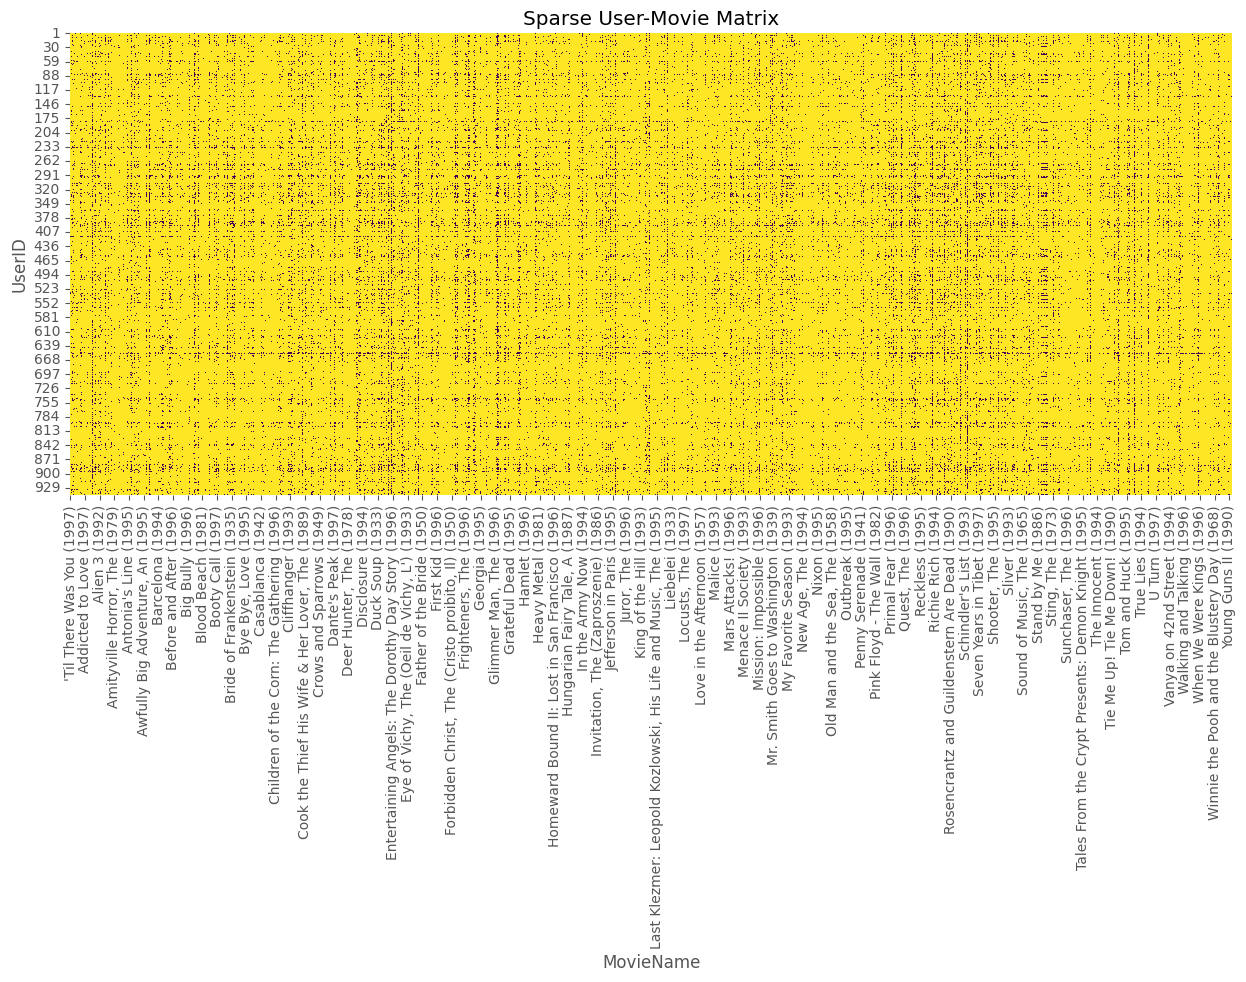

In [30]:
plt.figure(figsize=(15,6))

sns.heatmap(

    movie_matrix.isnull(),

    cbar=False,

    cmap="viridis"

)

plt.title("Sparse User-Movie Matrix")

plt.show()

In [31]:
movie_matrix_filled = movie_matrix.fillna(0)

movie_matrix_filled.head()

MovieName,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
UserID,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,2.0,5.0,0.0,0.0,3.0,4.0,0.0,0.0,...,0.0,0.0,0.0,5.0,3.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,2.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,...,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,4.0,0.0


In [32]:
from sklearn.decomposition import TruncatedSVD

In [33]:
# Hum 20 hidden features create karenge

svd = TruncatedSVD(

    n_components=20,

    random_state=42

)

In [34]:
# User-Movie Matrix ko latent features me convert kar rahe hain

latent_matrix = svd.fit_transform(movie_matrix_filled)

In [35]:
print(latent_matrix.shape)

(943, 20)


In [36]:
# convert into dataframe
latent_df = pd.DataFrame(

    latent_matrix,

    columns=[

        f"Latent_Feature_{i}"

        for i in range(1,21)

    ]

)

latent_df.head()

,Latent_Feature_1,Latent_Feature_2,Latent_Feature_3,Latent_Feature_4,Latent_Feature_5,Latent_Feature_6,Latent_Feature_7,Latent_Feature_8,Latent_Feature_9,Latent_Feature_10,Latent_Feature_11,Latent_Feature_12,Latent_Feature_13,Latent_Feature_14,Latent_Feature_15,Latent_Feature_16,Latent_Feature_17,Latent_Feature_18,Latent_Feature_19,Latent_Feature_20
0,42.043422,-1.664978,-1.504604,-13.231994,-1.373365,-2.455666,10.685556,2.041899,-6.293838,1.823945,0.255300,0.965946,-3.399486,-3.290653,-0.355788,0.070967,-6.067224,-1.189220,-2.724673,0.382604
1,8.949614,11.332480,11.399630,2.693287,2.249727,-0.804742,2.221721,0.668747,-3.773641,-0.413119,6.968479,-0.814020,0.036471,2.348019,2.948680,-1.624769,-0.848163,0.784236,0.837058,-0.252315
2,3.618921,6.239958,5.156248,3.988125,-7.171588,-0.538858,0.599231,0.324845,2.399355,-0.691615,-1.154450,-0.561353,-0.435302,-0.638429,-1.248912,0.596753,-0.414176,-1.696308,-1.979178,-1.231969
3,3.847190,5.089568,2.793737,2.845713,-4.194949,1.744210,1.404329,0.967066,2.233143,0.762129,-0.319537,1.241738,0.613954,0.717636,-3.505909,1.162587,0.430708,-1.475791,-0.580495,1.050211
4,20.988305,-2.175143,-10.056876,-2.370127,-1.517597,1.975840,12.088268,-8.998501,1.357922,2.134757,4.501776,5.149882,-0.992737,-0.250668,2.527993,-2.139476,-0.898429,-0.340842,1.987904,-1.545475


In [37]:
print(svd.explained_variance_ratio_)

[0.15436434 0.04822062 0.03943988 0.02219442 0.02226884 0.01831
 0.01405944 0.01322407 0.0101513  0.00883626 0.00774551 0.00768292
 0.0071855  0.00628032 0.0061802  0.00592329 0.00541346 0.00534663
 0.00511576 0.00485806]


In [38]:
print(

    sum(

        svd.explained_variance_ratio_

    )

)

0.4128008099126247


In [39]:
for i, value in enumerate(

    svd.explained_variance_ratio_

):

    print(

        f"Latent Feature {i+1} : {value:.4f}"

    )

Latent Feature 1 : 0.1544
Latent Feature 2 : 0.0482
Latent Feature 3 : 0.0394
Latent Feature 4 : 0.0222
Latent Feature 5 : 0.0223
Latent Feature 6 : 0.0183
Latent Feature 7 : 0.0141
Latent Feature 8 : 0.0132
Latent Feature 9 : 0.0102
Latent Feature 10 : 0.0088
Latent Feature 11 : 0.0077
Latent Feature 12 : 0.0077
Latent Feature 13 : 0.0072
Latent Feature 14 : 0.0063
Latent Feature 15 : 0.0062
Latent Feature 16 : 0.0059
Latent Feature 17 : 0.0054
Latent Feature 18 : 0.0053
Latent Feature 19 : 0.0051
Latent Feature 20 : 0.0049


In [41]:
print(svd.singular_values_) #Singular Values -> Importance of Hidden Features. Higher More Important.

[640.39419917 244.5502181  217.66028674 158.82046654 158.09802877
 145.69280412 126.50234478 121.87505842 106.74990394  99.62804368
  93.71161957  93.04955057  89.77424628  83.91530063  83.5242871
  81.57136718  78.09598615  77.63504394  75.71044006  73.78725177]


In [42]:
print(svd.components_) # yeh btata h ki  hr movie hideen features mein kitna contribute kr rhi h

[[ 1.62398975e-03  6.81743116e-04  1.95875351e-02 ...  5.60482301e-04
   2.22406783e-03  3.57920698e-04]
 [ 2.69844092e-03 -1.05195959e-03  2.31820837e-02 ...  1.51810137e-03
   3.33249684e-03 -2.54427246e-05]
 [ 2.09832106e-04  1.62157313e-03 -2.25480528e-02 ...  1.05537748e-04
  -2.25233312e-03  1.25501019e-03]
 ...
 [ 5.26459977e-03 -4.58650092e-03  2.26341481e-02 ...  2.35869869e-03
   6.56156116e-03 -9.01988404e-03]
 [-6.25719798e-03  6.25702473e-03  1.36333422e-02 ... -3.41432914e-03
  -5.64320913e-03  8.47776439e-04]
 [ 6.63598182e-03 -1.32363312e-03 -3.70637427e-02 ... -8.71497491e-03
   3.85126072e-03  3.67080657e-04]]


In [43]:
# future mein new user aa gye
new_user = movie_matrix_filled.iloc[:5]

new_user_features = svd.transform(new_user)

print(new_user_features)

[[ 4.20434222e+01 -1.66497794e+00 -1.50460384e+00 -1.32319945e+01
  -1.37336523e+00 -2.45566563e+00  1.06855565e+01  2.04189924e+00
  -6.29383784e+00  1.82394499e+00  2.55299858e-01  9.65946019e-01
  -3.39948574e+00 -3.29065287e+00 -3.55788365e-01  7.09674737e-02
  -6.06722446e+00 -1.18922005e+00 -2.72467338e+00  3.82603978e-01]
 [ 8.94961410e+00  1.13324797e+01  1.13996300e+01  2.69328709e+00
   2.24972725e+00 -8.04742154e-01  2.22172081e+00  6.68746609e-01
  -3.77364122e+00 -4.13119340e-01  6.96847940e+00 -8.14019775e-01
   3.64711030e-02  2.34801875e+00  2.94868022e+00 -1.62476882e+00
  -8.48163245e-01  7.84235550e-01  8.37058119e-01 -2.52315403e-01]
 [ 3.61892108e+00  6.23995850e+00  5.15624788e+00  3.98812537e+00
  -7.17158778e+00 -5.38858360e-01  5.99230633e-01  3.24844862e-01
   2.39935477e+00 -6.91614990e-01 -1.15444976e+00 -5.61352830e-01
  -4.35302254e-01 -6.38429291e-01 -1.24891181e+00  5.96753121e-01
  -4.14175505e-01 -1.69630800e+00 -1.97917835e+00 -1.23196869e+00]
 [ 3.84

In [44]:
print(

    "Original Shape :",

    movie_matrix_filled.shape

)

print(

    "Reduced Shape :",

    latent_matrix.shape

)

Original Shape : (943, 1664)
Reduced Shape : (943, 20)


In [45]:
print("="*50)

print(

    "Original Features :",

    movie_matrix_filled.shape[1]

)

print(

    "Latent Features :",

    latent_matrix.shape[1]

)

print(

    "Variance Preserved :",

    round(

        sum(

            svd.explained_variance_ratio_

        )*100,

        2

    ),

    "%"

)

print("="*50)

Original Features : 1664
Latent Features : 20
Variance Preserved : 41.28 %


**Cosine Similarity + Movie Recommendation Engine**

In [46]:
from sklearn.metrics.pairwise import cosine_similarity

In [47]:
svd.components_.shape

(20, 1664)

In [48]:
movie_features = svd.components_.T

In [49]:
movie_similarity = cosine_similarity(movie_features)

In [50]:
print(movie_similarity.shape) # har movie har movie se compare hui h

(1664, 1664)


In [51]:
movie_similarity_df = pd.DataFrame(

    movie_similarity,

    index=movie_matrix_filled.columns,

    columns=movie_matrix_filled.columns

)

In [52]:
movie_similarity_df.head()

MovieName,'Til There Was You (1997),1-900 (1994),101 Dalmatians (1996),12 Angry Men (1957),187 (1997),2 Days in the Valley (1996),"20,000 Leagues Under the Sea (1954)",2001: A Space Odyssey (1968),3 Ninjas: High Noon At Mega Mountain (1998),"39 Steps, The (1935)",...,Yankee Zulu (1994),Year of the Horse (1997),You So Crazy (1994),Young Frankenstein (1974),Young Guns (1988),Young Guns II (1990),"Young Poisoner's Handbook, The (1995)",Zeus and Roxanne (1997),unknown,Á köldum klaka (Cold Fever) (1994)
MovieName,,,,,,,,,,,,,,,,,,,,,
'Til There Was You (1997),1.000000,-0.293408,-0.341219,0.007388,0.527196,0.364528,-0.070628,-0.173179,-0.409533,-0.073284,...,-0.389568,0.280013,0.156880,-0.330175,0.116506,0.452394,-0.256835,-0.274983,0.670991,0.028608
1-900 (1994),-0.293408,1.000000,0.121772,-0.038410,0.006489,-0.077575,-0.090865,0.220859,0.163243,0.178671,...,0.463696,-0.100940,-0.133109,0.245124,-0.351704,-0.291073,0.359178,0.058124,0.068683,0.464376
101 Dalmatians (1996),-0.341219,0.121772,1.000000,-0.221062,-0.066790,-0.209220,0.311850,0.240793,0.275367,0.089036,...,0.308233,0.140271,-0.268444,0.213425,-0.316218,-0.398704,0.203608,0.707725,-0.114286,-0.059300
12 Angry Men (1957),0.007388,-0.038410,-0.221062,1.000000,-0.127806,0.222873,0.158005,-0.127401,0.171935,0.537412,...,0.211910,-0.440315,0.494624,-0.009182,0.217979,0.173863,-0.049793,0.189571,-0.203054,-0.305935
187 (1997),0.527196,0.006489,-0.066790,-0.127806,1.000000,0.315764,0.080309,0.075177,-0.113044,0.029566,...,-0.183796,0.432311,0.009741,-0.045310,-0.050731,0.177998,0.347077,0.066656,0.557160,0.356249


In [53]:
# Recommendation function
def recommend_movies(movie_name, top_n=10):

    # Check if movie exists
    if movie_name not in movie_similarity_df.columns:

        return "Movie Not Found!"

    # Similarity scores
    similarity_scores = movie_similarity_df[movie_name]

    # Sort in descending order
    recommendations = similarity_scores.sort_values(

        ascending=False

    )

    # Remove same movie
    recommendations = recommendations.iloc[1:top_n+1]

    return recommendations

In [54]:
recommend_movies("Toy Story (1995)")

,Toy Story (1995)
MovieName,
"Hunchback of Notre Dame, The (1996)",0.678033
Willy Wonka and the Chocolate Factory (1971),0.639954
Mr. Holland's Opus (1995),0.638963
Star Trek: First Contact (1996),0.621098
Hercules (1997),0.553269
James and the Giant Peach (1996),0.523828
"Close Shave, A (1995)",0.509387
Beauty and the Beast (1991),0.497016
101 Dalmatians (1996),0.494307


In [55]:
result = recommend_movies(

    "Toy Story (1995)"

)

result = result.reset_index()

result.columns = [

    "Recommended Movie",

    "Similarity Score"

]

result

,Recommended Movie,Similarity Score
0,"Hunchback of Notre Dame, The (1996)",0.678033
1,Willy Wonka and the Chocolate Factory (1971),0.639954
2,Mr. Holland's Opus (1995),0.638963
3,Star Trek: First Contact (1996),0.621098
4,Hercules (1997),0.553269
5,James and the Giant Peach (1996),0.523828
6,"Close Shave, A (1995)",0.509387
7,Beauty and the Beast (1991),0.497016
8,101 Dalmatians (1996),0.494307
9,Mystery Science Theater 3000: The Movie (1996),0.482173


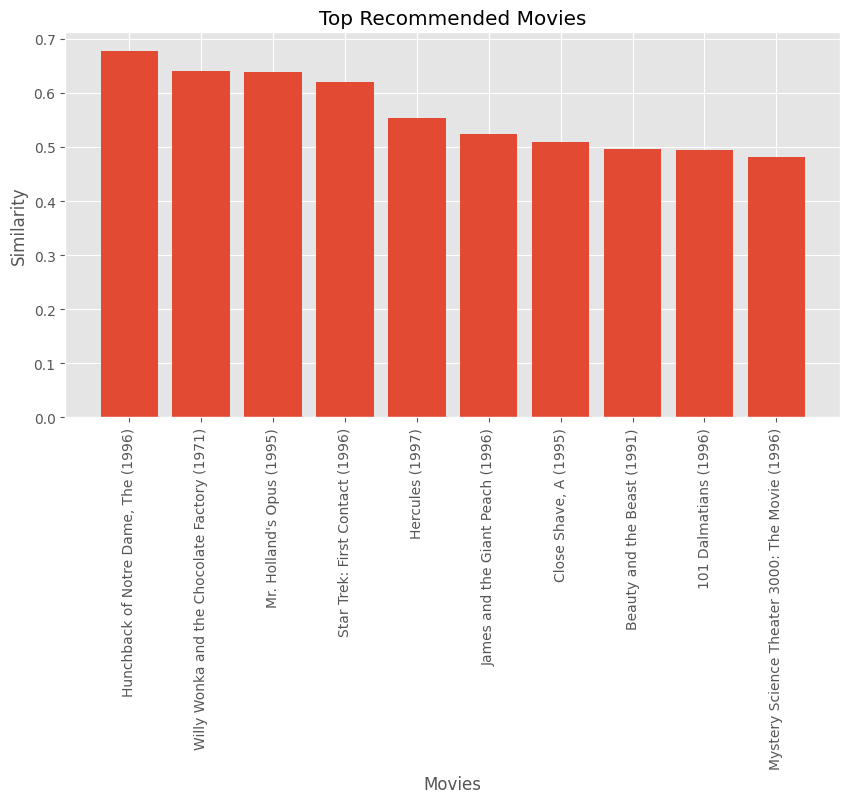

In [56]:
plt.figure(figsize=(10,5))

plt.bar(

    result["Recommended Movie"],

    result["Similarity Score"]

)

plt.xticks(rotation=90)

plt.title(

    "Top Recommended Movies"

)

plt.xlabel("Movies")

plt.ylabel("Similarity")

plt.show()

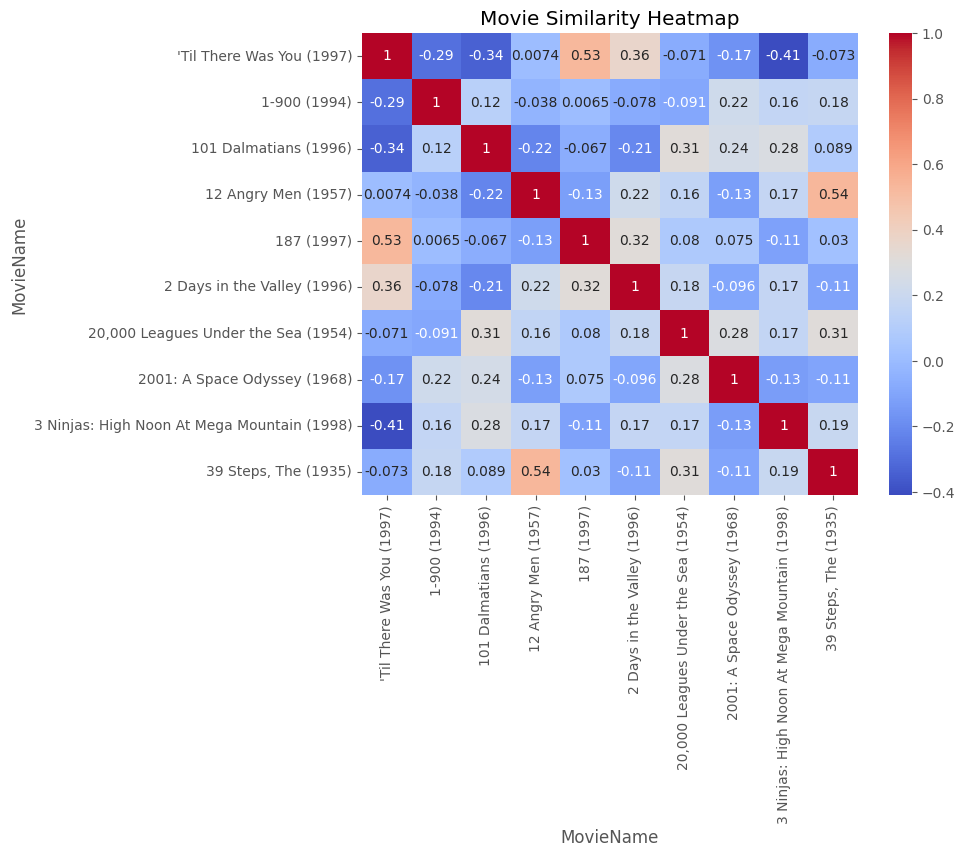

In [57]:
plt.figure(figsize=(8,6))

sns.heatmap(

    movie_similarity_df.iloc[:10,:10],

    annot=True,

    cmap="coolwarm"

)

plt.title(

    "Movie Similarity Heatmap"

)

plt.show()

In [58]:
movies_to_test = [

    "Toy Story (1995)",

    "Batman (1989)",

    "Titanic (1997)"

]

for movie in movies_to_test:

    print("="*50)

    print("Movie :", movie)

    print("="*50)

    print(recommend_movies(movie))

    print()

Movie : Toy Story (1995)
MovieName
Hunchback of Notre Dame, The (1996)               0.678033
Willy Wonka and the Chocolate Factory (1971)      0.639954
Mr. Holland's Opus (1995)                         0.638963
Star Trek: First Contact (1996)                   0.621098
Hercules (1997)                                   0.553269
James and the Giant Peach (1996)                  0.523828
Close Shave, A (1995)                             0.509387
Beauty and the Beast (1991)                       0.497016
101 Dalmatians (1996)                             0.494307
Mystery Science Theater 3000: The Movie (1996)    0.482173
Name: Toy Story (1995), dtype: float64

Movie : Batman (1989)
MovieName
Batman Returns (1992)                0.863091
True Lies (1994)                     0.797071
Die Hard: With a Vengeance (1995)    0.793024
Top Gun (1986)                       0.786931
Crow, The (1994)                     0.747729
Jurassic Park (1993)                 0.744756
Stargate (1994)            